# Phase 2 Task 1: First EDA on NorthStar Goods

## Objective

This is a first-pass exploratory data analysis of the raw NorthStar Goods order export.

The purpose of this analysis is to understand the structure, missingness, distributions, relationships and data-quality issues in the dataset before any cleaning or treatment is performed.

**Important:** The raw dataset is not modified in this notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Load dataset
df = pd.read_csv("../../dataset/northstar_goods.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../../dataset/northstar_goods.csv'

In [ ]:
#Display first five rows
df.head()

,order_id,order_date,customer_id,region,product_category,quantity,unit_price,discount_pct,payment_method,total_amount
0,NS-00522,2024-02-23,CUST-0214,West,Toys,7.0,173.91,0,Card,1217.37
1,NS-00740,2024-11-23,CUST-0062,London,Food & Drink,1.0,89.36,5,Card,84.89
2,NS-00824,2024-08-25,CUST-0264,Scotland,Sports,2.0,8.15,10,Card,14.67
3,NS-00663,2024-01-13,CUST-0056,London,Clothing,9.0,178.22,0,Card,1603.98
4,NS-00412,2024-03-24,CUST-0169,Midlands,Toys,5.0,NaN,0,PayPal,142.65


In [ ]:
# Display the last five rows of the dataset 
# to confirm that the file has been read through to the end.
df.tail()

,order_id,order_date,customer_id,region,product_category,quantity,unit_price,discount_pct,payment_method,total_amount
997,NS-00107,2024-10-11,CUST-0074,North,Electronics,8.0,67.63,10,Card,486.94
998,NS-00271,2024-04-17,CUST-0111,Midlands,Beauty,2.0,192.02,20,Bank Transfer,307.23
999,NS-00861,2024-12-19,CUST-0222,Scotland,Electronics,6.0,95.05,5,Cash,541.78
1000,NS-00436,2024-02-15,CUST-0031,Midlands,Sports,10.0,113.26,5,Card,1075.97
1001,NS-00103,2024-10-20,CUST-0276,London,Clothing,3.0,191.96,5,Card,547.09


In [ ]:
# Display the names of all columns in the dataset.
df.columns

Index(['order_id', 'order_date', 'customer_id', 'region', 'product_category',
       'quantity', 'unit_price', 'discount_pct', 'payment_method',
       'total_amount'],
      dtype='str')

## 1. Shape and Data Types

This examines the size of the dataset, the data types assigned by pandas and the amount of memory used by the DataFrame.

In [ ]:
# Number of rows and columns in the DataFrame.
# df.shape returns the result as (rows, columns).
df.shape

(1002, 10)

In [ ]:
# Store the number of rows and columns separately.
rows, columns = df.shape

# Print the dataset dimensions in a readable format.
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 1002
Number of columns: 10


In [ ]:
# Display the data type assigned to every column.
# To identify columns that may have been interpreted incorrectly.
df.dtypes

order_id                str
order_date              str
customer_id             str
region                  str
product_category        str
quantity            float64
unit_price          float64
discount_pct          int64
payment_method          str
total_amount        float64
dtype: object

In [ ]:
# Display detailed information about the DataFrame.
# memory_usage="deep" gives a more accurate memory estimate.
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1002 non-null   str    
 1   order_date        1002 non-null   str    
 2   customer_id       1002 non-null   str    
 3   region            1002 non-null   str    
 4   product_category  1002 non-null   str    
 5   quantity          996 non-null    float64
 6   unit_price        972 non-null    float64
 7   discount_pct      1002 non-null   int64  
 8   payment_method    972 non-null    str    
 9   total_amount      1002 non-null   float64
dtypes: float64(3), int64(1), str(6)
memory usage: 410.4 KB


In [ ]:
# Calculate the total memory used by the DataFrame in bytes.
memory_usage = df.memory_usage(deep=True).sum()

# Convert the memory usage to megabytes and display it.
print(f"Memory usage: {memory_usage / 1024**2:.2f} MB")

Memory usage: 0.40 MB


#### Interpretation for Shape and Type Findings

The NorthStar Goods dataset contains 1002 rows and 10 columns.

The `order_date` column is stored as a string (`str`) rather than a datetime type. This is not ideal for date-based analysis because dates should normally be stored as a datetime type to allow operations such as sorting, filtering and extracting months or years.

The numerical columns are stored as follows: `quantity` is `float64`, `unit_price` is `float64`, `discount_pct` is `int64`, and `total_amount` is `float64`. These data types are suitable for numerical analysis, although `quantity` being stored as a float may be worth investigating because quantities are normally whole units.

The text-based columns, including `order_id`, `customer_id`, `region`, `product_category` and `payment_method`, are stored as strings, which is appropriate for categorical or identifier information.

The dataset uses approximately 0.40 MB of memory.

No data types or values have been changed because this is intended to diagnose the raw export only.

## 2. Missingness

This identifies missing values in every column and highlights which fields are most affected.

In [ ]:
# Count the number of missing values in every column.
missing_counts = df.isna().sum()

# Sort the results so columns with the most missing values appear first.
missing_counts = missing_counts.sort_values(ascending=False)

# Display the missing-value counts.
missing_counts

unit_price          30
payment_method      30
quantity             6
order_id             0
order_date           0
customer_id          0
region               0
product_category     0
discount_pct         0
total_amount         0
dtype: int64

In [ ]:
# Calculate the percentage of rows that are missing in each column.
missing_percentage = (df.isna().mean() * 100).sort_values(ascending=False)

# Display the missing percentages.
missing_percentage

unit_price          2.994012
payment_method      2.994012
quantity            0.598802
order_id            0.000000
order_date          0.000000
customer_id         0.000000
region              0.000000
product_category    0.000000
discount_pct        0.000000
total_amount        0.000000
dtype: float64

In [ ]:
# Create a summary table containing both missing counts and percentages.
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percentage
})

# Display the missingness summary.
missing_summary

,missing_count,missing_percentage
unit_price,30,2.994012
payment_method,30,2.994012
quantity,6,0.598802
order_id,0,0.000000
order_date,0,0.000000
customer_id,0,0.000000
region,0,0.000000
product_category,0,0.000000
discount_pct,0,0.000000
total_amount,0,0.000000


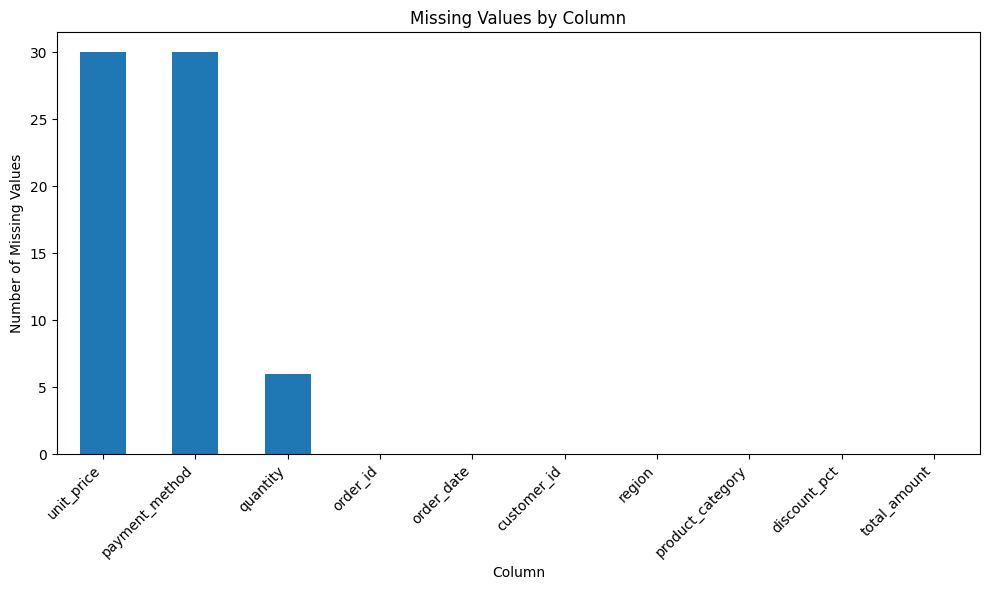

In [ ]:
# Create a bar chart showing the number of missing values in each column.
plt.figure(figsize=(10, 6))

# Plot the missing-value counts.
missing_counts.plot(kind="bar")

# Add a descriptive title.
plt.title("Missing Values by Column")

# Label the x-axis.
plt.xlabel("Column")

# Label the y-axis.
plt.ylabel("Number of Missing Values")

# Rotate the column names so they are easier to read.
plt.xticks(rotation=45, ha="right")

# Adjust the layout so labels are not cut off.
plt.tight_layout()

# Display the chart.
plt.show()

#### Interpretation of Missingness Finding

The columns most affected by missing values are `payment_method` and `unit_price`, each with 30 missing values (~3.0% of rows). `quantity` has a smaller number of missing values: 6 rows (~0.6%).

These missing values matter because `unit_price` and `quantity` both feed directly into `total_amount`, so rows missing either field can't be independently verified, and `payment_method` gaps limit any payment-method segmentation.

## 3. Univariate Analysis

This examines each variable individually. Numerical variables are explored using summary statistics and histograms, while categorical variables are examined using value counts and horizontal bar charts.

In [ ]:
# Numeric column 
# Identify columns pandas currently recognises as numeric.
numeric_columns = df.select_dtypes(include="number").columns
numeric_columns

Index(['quantity', 'unit_price', 'discount_pct', 'total_amount'], dtype='str')

In [ ]:
# Summary statistics (count, mean, std, quartiles, min/max) for all numeric columns.
df[numeric_columns].describe()

,quantity,unit_price,discount_pct,total_amount
count,996.000000,972.000000,1002.000000,1002.000000
mean,5.997992,110.347829,4.620758,515.300040
std,15.921731,322.648767,5.883984,423.845374
min,1.000000,2.130000,0.000000,2.020000
25%,3.000000,51.762500,0.000000,171.905000
50%,6.000000,100.410000,0.000000,401.085000
75%,8.000000,149.817500,10.000000,751.685000
max,500.000000,9999.990000,20.000000,1974.000000


### 3.1 Quantity

In [ ]:
# Descriptive statistics for order quantity.
df["quantity"].describe()


count    996.000000
mean       5.997992
std       15.921731
min        1.000000
25%        3.000000
50%        6.000000
75%        8.000000
max      500.000000
Name: quantity, dtype: float64

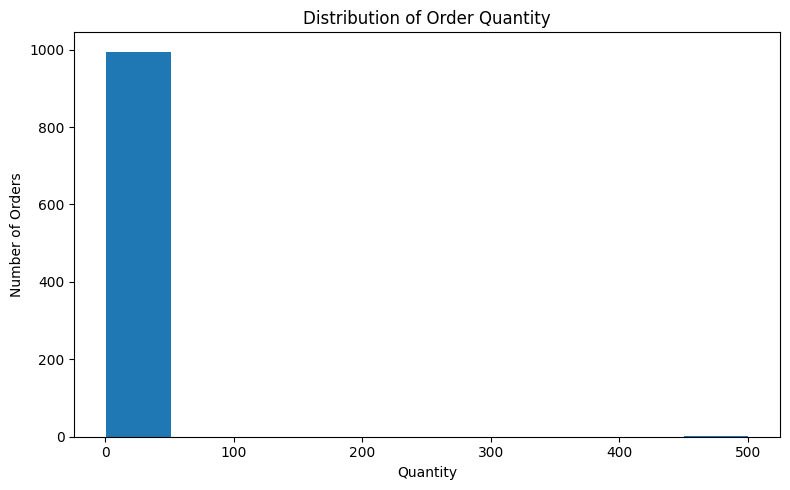

In [ ]:
# Histogram of order quantity distribution.
plt.figure(figsize=(8, 5))
# dropna() only affects this plot, it does not change df itself.
plt.hist(df["quantity"].dropna(), bins=10)
plt.title("Distribution of Order Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

#### **Quantity Finding:** 
Quantities range from 1–500, but the middle 50% of orders (IQR) sit between 3 and 8 units, with a median of 6. The distribution is dominated by one extreme value; 500 units, an order of magnitude above the next-highest value (10), which compresses the histogram and is very likely a data-entry error.

### 3.2 Unit Price

In [ ]:
# Descriptive statistics for unit price.
df["unit_price"].describe()

count     972.000000
mean      110.347829
std       322.648767
min         2.130000
25%        51.762500
50%       100.410000
75%       149.817500
max      9999.990000
Name: unit_price, dtype: float64

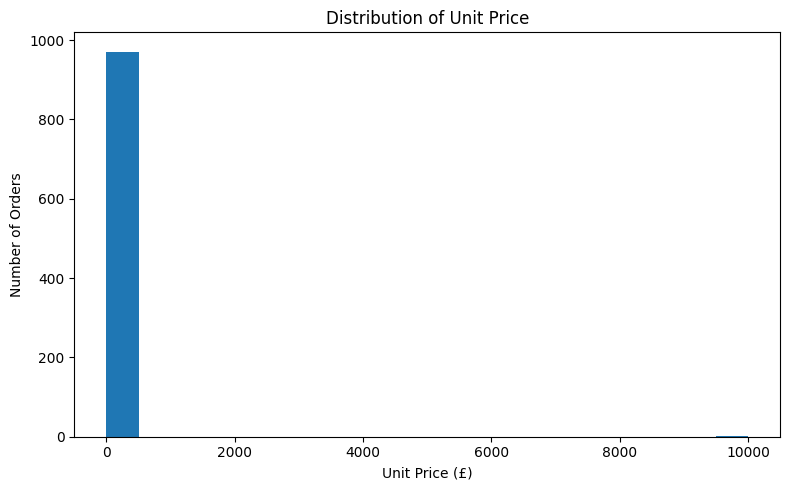

In [ ]:
# Histogram of unit price distribution.
plt.figure(figsize=(8, 5))
plt.hist(df["unit_price"].dropna(), bins=20)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price (£)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

#### **Unit Price Finding:** 
Unit prices range from £2.13 to £199.88 for the vast majority of orders (median £100.41), which is roughly evenly spread, except for a single value of £9,999.99, about 50x the next-highest price, which is an isolated statistical outlier (IQR upper bound ≈ £297) and skews the mean up to £110.35.

### 3.3 Discount Percentage

In [ ]:
# Descriptive statistics for discount percentage.
df["discount_pct"].describe()

count    1002.000000
mean        4.620758
std         5.883984
min         0.000000
25%         0.000000
50%         0.000000
75%        10.000000
max        20.000000
Name: discount_pct, dtype: float64

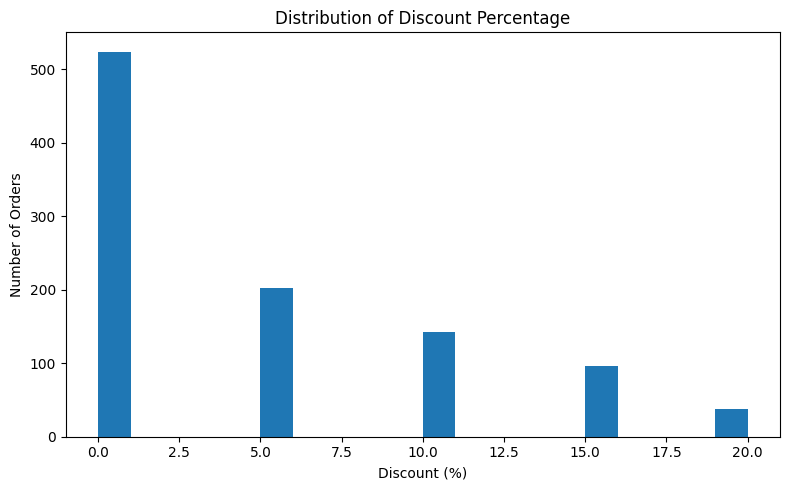

In [ ]:
# Histogram of discount percentage
plt.figure(figsize=(8, 5))
plt.hist(df["discount_pct"].dropna(), bins=20)
plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

#### **Discount Percentage Finding:** 
Discounts only take five discrete values: 0%, 5%, 10%, 15%, 20%, rather than being continuous. 0% is by far the most common (524 of 1,002 orders, over half), and the median and 25th percentile are both 0%, so most orders receive no discount at all.

### 3.4 Total Order Amount

In [ ]:
# Descriptive statistics for total order value.
df["total_amount"].describe()

count    1002.000000
mean      515.300040
std       423.845374
min         2.020000
25%       171.905000
50%       401.085000
75%       751.685000
max      1974.000000
Name: total_amount, dtype: float64

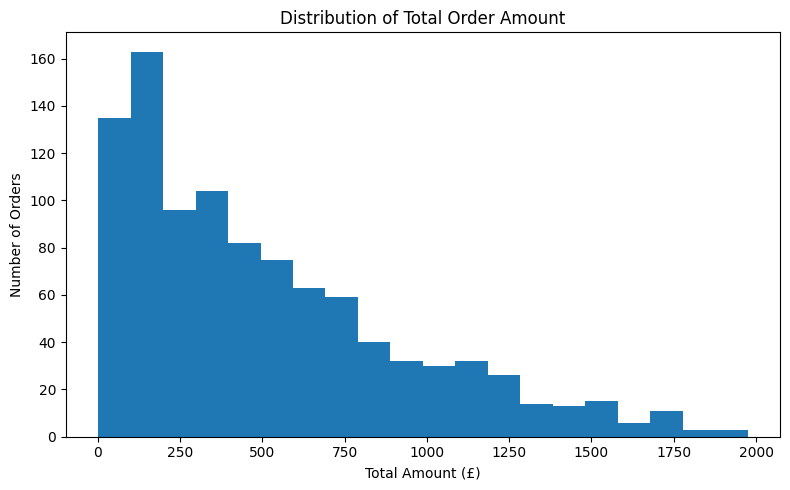

In [ ]:
# Histogram of total order value.
plt.figure(figsize=(8, 5))
plt.hist(df["total_amount"].dropna(), bins=20)
plt.title("Distribution of Total Order Amount")
plt.xlabel("Total Amount (£)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

#### **Total Order Amount Finding:** 
Total order value ranges from £2.02 to £1,974.00, right-skewed with a median of £401.09 well below the mean of £515.30, which is consistent with a long tail of higher-value orders and no single value that looks obviously invalid.

### Categorical Columns

In [ ]:
# Identify categorical/text columns
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

categorical_columns

Index(['order_id', 'order_date', 'customer_id', 'region', 'product_category',
       'payment_method'],
      dtype='str')

### 3.5 Region

In [ ]:
# Count orders by region.
region_counts = df["region"].value_counts(dropna=False)
region_counts

region
North       163
South       159
London      138
West        120
East        113
Midlands    106
Scotland     94
Wales        69
east          5
EAST          4
WEST          4
south         4
north         4
MIDLANDS      4
LONDON        3
WALES         2
NORTH         2
scotland      2
west          2
london        2
SOUTH         1
midlands      1
Name: count, dtype: int64

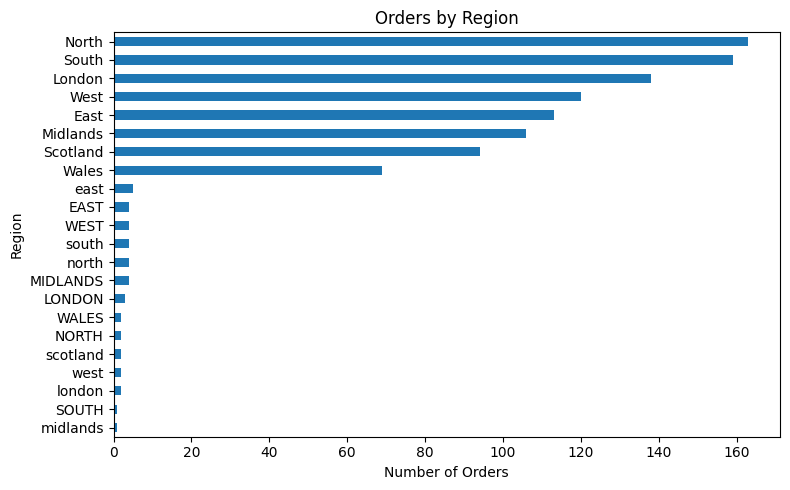

In [ ]:
# Horizontal bar chart of orders by region, smallest category at the bottom.
plt.figure(figsize=(8, 5))
region_counts.sort_values().plot(kind="barh")
plt.title("Orders by Region")
plt.xlabel("Number of Orders")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

#### **Region Finding:** 
North (163) and South (159) have the most orders in their clean form, Wales (69) the fewest, but this raw count is inflated to 22 distinct labels by casing duplicates (e.g. `east`: 5, `EAST`: 4, alongside `East`: 113), which should be folded together before regional comparisons are trusted.

### 3.6 Product Category

In [ ]:
# Count orders by product category.
category_counts = df["product_category"].value_counts(dropna=False)
category_counts

product_category
Home & Garden    164
Electronics      157
Beauty           147
Sports           139
Clothing         138
Food & Drink     137
Toys             120
Name: count, dtype: int64

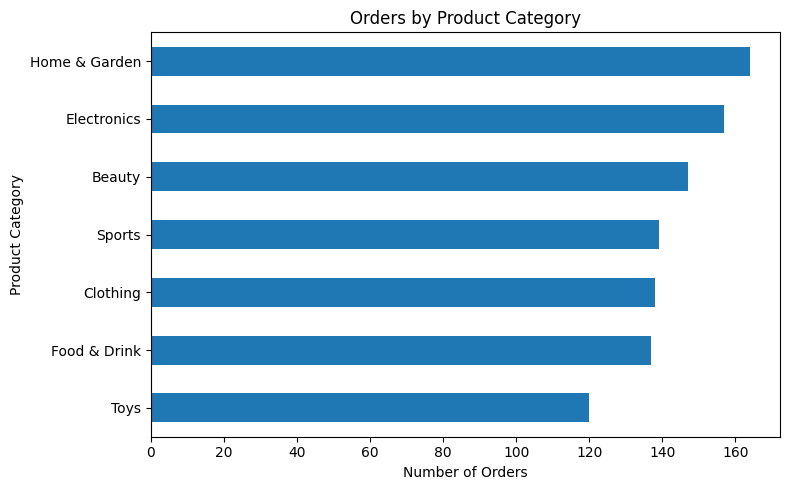

In [ ]:
# Horizontal bar chart of orders by product category.
plt.figure(figsize=(8, 5))
category_counts.sort_values().plot(kind="barh")
plt.title("Orders by Product Category")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

#### **Product Category Finding:** 
Order volume is highest in Home & Garden (164) and lowest in Toys (120), but the seven categories are fairly evenly used overall, and unlike `region`, there's no casing inconsistency here.

### 3.7 Payment Method

In [ ]:
# Count orders by payment method, including missing values.
payment_counts = df["payment_method"].value_counts(dropna=False)
payment_counts

payment_method
Card             524
Cash             196
PayPal           175
Bank Transfer     53
NaN               30
card              13
cash               5
paypal             5
bank transfer      1
Name: count, dtype: int64

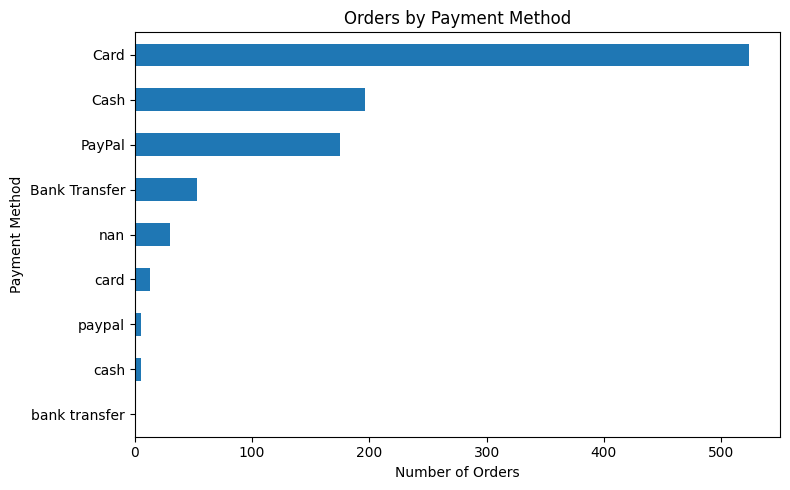

In [ ]:
# Horizontal bar chart of orders by payment method.
plt.figure(figsize=(8, 5))
payment_counts.sort_values().plot(kind="barh")
plt.title("Orders by Payment Method")
plt.xlabel("Number of Orders")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

#### **Payment Method Finding:** 
Card is by far the most common method (524 clean + 13 lowercase `card` = 537 true total), followed by Cash, PayPal, then Bank Transfer. 30 rows (3.0%) have no payment method recorded, and once casing duplicates are folded in, there are only 4 true payment methods, not 8.

### 3.8 Return Status

Left for now.

## 4. Bivariate Analysis

This examines relationships between pairs of variables to identify patterns that may have business relevance.

### 4.1 Region vs Total Order Amount

<Figure size 1000x600 with 0 Axes>

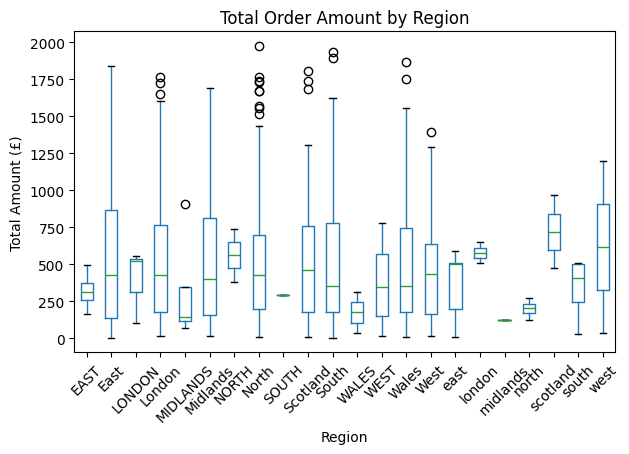

In [ ]:
# Boxplot comparing total order amount across regions.
plt.figure(figsize=(10, 6))
df.boxplot(column="total_amount", by="region", grid=False)
plt.title("Total Order Amount by Region")
plt.suptitle("")  # remove pandas' automatic secondary title
plt.xlabel("Region")
plt.ylabel("Total Amount (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Finding:** 
Each box shows the spread of `total_amount` (£, y-axis) for orders from that region (x-axis).Medians sit in a fairly tight band across regions, from £332 (Wales) up to £467 (Scotland), so no region has a significant higher "typical" order. The main irregularity is a cluster of high-value outlier orders (£1,500–£1,974) sitting well above the whiskers in North, London, Scotland, South, Wales, and West. These are individually large orders, not evidence that those regions trade at a different scale overall. Wales's box sits lowest overall on every quartile. This comparison is still slightly distorted by the casing duplicates in `region` splitting a few regions into extra boxes.

### 4.2 Product Category vs Discount Percentage

<Figure size 1000x600 with 0 Axes>

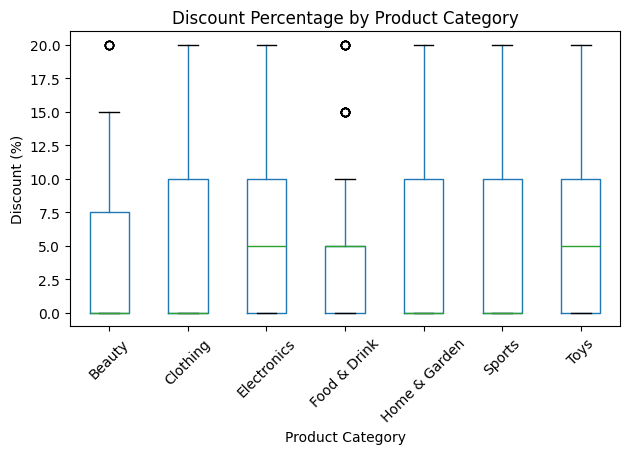

In [ ]:
# Boxplot comparing discount percentage across product categories.
plt.figure(figsize=(10, 6))
df.boxplot(column="discount_pct", by="product_category", grid=False)
plt.title("Discount Percentage by Product Category")
plt.suptitle("")
plt.xlabel("Product Category")
plt.ylabel("Discount (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Finding:** 
Discount levels are broadly similar across all seven product categories, suggesting discounts are applied by an order-level rule rather than as a deliberate per-category strategy.

### 4.3 Quantity vs Total Order Amount

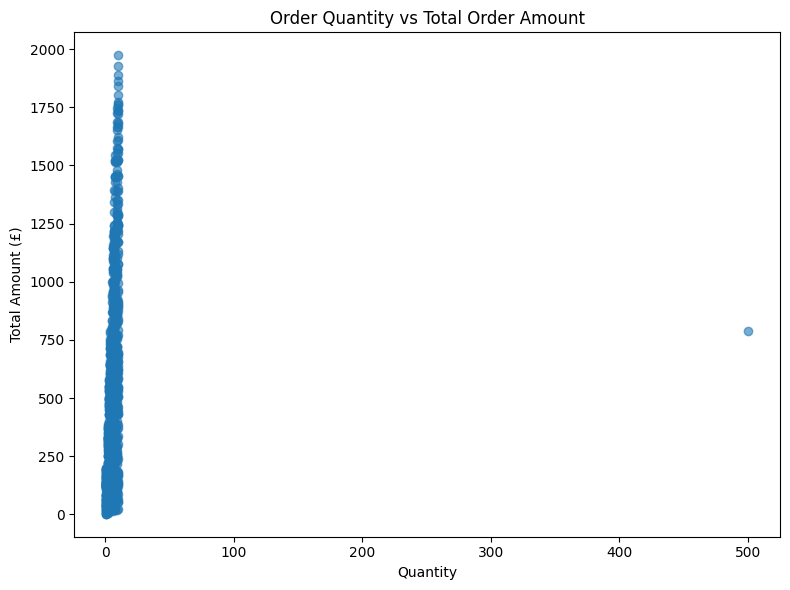

In [ ]:
# Scatter plot: quantity ordered vs total order amount.
plt.figure(figsize=(8, 6))
plt.scatter(df["quantity"], df["total_amount"], alpha=0.6)
plt.title("Order Quantity vs Total Order Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount (£)")
plt.tight_layout()
plt.show()

#### **Finding:** 
There is a loose positive relationship, total amount tends to rise with quantity, but the single `quantity = 500` outlier sits far outside the rest of the cloud and stretches the x-axis, making the pattern among the other ~1,000 orders harder to read at this scale.

## 5. Data-Quality Catalogue

The following checks are diagnostic only. No values are changed, no rows are removed and no missing values are filled.

In [ ]:
# Count fully duplicated rows in the raw dataset.
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 2


In [ ]:
# Display duplicated rows. keep=False flags every copy, not just the second occurrence.
df[df.duplicated(keep=False)]

,order_id,order_date,customer_id,region,product_category,quantity,unit_price,discount_pct,payment_method,total_amount
0,NS-00522,2024-02-23,CUST-0214,West,Toys,7.0,173.91,0,Card,1217.37
86,NS-00522,2024-02-23,CUST-0214,West,Toys,7.0,173.91,0,Card,1217.37
561,NS-00738,2024-05-01,CUST-0030,South,Home & Garden,10.0,145.50,0,Cash,1455.00
663,NS-00738,2024-05-01,CUST-0030,South,Home & Garden,10.0,145.50,0,Cash,1455.00


In [ ]:
# Count repeated order IDs. An order ID should normally be unique.
duplicate_order_ids = df["order_id"].duplicated().sum()
print("Duplicate order IDs:", duplicate_order_ids)

Duplicate order IDs: 2


In [ ]:
# Display all rows whose order_id occurs more than once.
duplicate_id_mask = df["order_id"].duplicated(keep=False)
df[duplicate_id_mask].sort_values("order_id")

,order_id,order_date,customer_id,region,product_category,quantity,unit_price,discount_pct,payment_method,total_amount
0,NS-00522,2024-02-23,CUST-0214,West,Toys,7.0,173.91,0,Card,1217.37
86,NS-00522,2024-02-23,CUST-0214,West,Toys,7.0,173.91,0,Card,1217.37
561,NS-00738,2024-05-01,CUST-0030,South,Home & Garden,10.0,145.50,0,Cash,1455.00
663,NS-00738,2024-05-01,CUST-0030,South,Home & Garden,10.0,145.50,0,Cash,1455.00


In [ ]:
# Check the current (raw) data type of order_date.
print("order_date dtype:", df["order_date"].dtype)

order_date dtype: str


In [ ]:
# Preview raw date values exactly as loaded.
df["order_date"].head(20)

0     2024-02-23
1     2024-11-23
2     2024-08-25
3     2024-01-13
4     2024-03-24
5     2024-09-21
6     2024-07-03
7     2024-10-25
8     2024-11-04
9     2024-08-08
10    2024-04-13
11    2024-04-30
12    2024-10-16
13    2024-02-10
14    2024-09-09
15    2024-01-16
16    2024-04-10
17    2024-09-25
18    2024-04-13
19    2024-10-07
Name: order_date, dtype: str

In [ ]:
# Temporary diagnostic conversion.
# errors="coerce" turns unparseable values into NaT so we can count them.
parsed_dates = pd.to_datetime(df["order_date"], errors="coerce")
invalid_date_count = parsed_dates.isna().sum()
print("Potentially invalid dates:", invalid_date_count)

Potentially invalid dates: 1


In [ ]:
# Show the original raw values that failed to parse, including order_id for context.
df.loc[parsed_dates.isna(), ["order_id", "order_date"]]

,order_id,order_date
29,NS-00838,2024-13-40


In [ ]:
# Count negative and zero quantities. Both would be invalid for a real order.
negative_quantity_count = (df["quantity"] < 0).sum()
zero_quantity_count = (df["quantity"] == 0).sum()
print("Negative quantities:", negative_quantity_count)
print("Zero quantities:", zero_quantity_count)

Negative quantities: 0
Zero quantities: 0


In [ ]:
# Count negative unit prices.
negative_price_count = (df["unit_price"] < 0).sum()
print("Negative unit prices:", negative_price_count)

Negative unit prices: 0


In [ ]:
# Count negative total order amounts.
negative_total_count = (df["total_amount"] < 0).sum()
print("Negative total amounts:", negative_total_count)

Negative total amounts: 0


In [ ]:
# Re-check discount_pct summary stats.
df["discount_pct"].describe()

count    1002.000000
mean        4.620758
std         5.883984
min         0.000000
25%         0.000000
50%         0.000000
75%        10.000000
max        20.000000
Name: discount_pct, dtype: float64

In [ ]:
# Flag discount values outside the sensible 0-100% range.
invalid_discount_mask = (df["discount_pct"] < 0) | (df["discount_pct"] > 100)
print("Potentially invalid discounts:", invalid_discount_mask.sum())

Potentially invalid discounts: 0


In [ ]:
# Full value counts for region, used to spot casing duplicates (e.g. West/WEST/west).
print("REGION")
print(df["region"].value_counts(dropna=False))

REGION
region
North       163
South       159
London      138
West        120
East        113
Midlands    106
Scotland     94
Wales        69
east          5
EAST          4
WEST          4
south         4
north         4
MIDLANDS      4
LONDON        3
WALES         2
NORTH         2
scotland      2
west          2
london        2
SOUTH         1
midlands      1
Name: count, dtype: int64


In [ ]:
# Full value counts for product_category to check for casing/spelling issues.
print("PRODUCT CATEGORY")
print(df["product_category"].value_counts(dropna=False))

PRODUCT CATEGORY
product_category
Home & Garden    164
Electronics      157
Beauty           147
Sports           139
Clothing         138
Food & Drink     137
Toys             120
Name: count, dtype: int64


In [ ]:
# Full value counts for payment_method to check for casing duplicates.
print("PAYMENT METHOD")
print(df["payment_method"].value_counts(dropna=False))

PAYMENT METHOD
payment_method
Card             524
Cash             196
PayPal           175
Bank Transfer     53
NaN               30
card              13
cash               5
paypal             5
bank transfer      1
Name: count, dtype: int64


In [ ]:
# Re-check unit_price summary stats.
df["unit_price"].describe()

count     972.000000
mean      110.347829
std       322.648767
min         2.130000
25%        51.762500
50%       100.410000
75%       149.817500
max      9999.990000
Name: unit_price, dtype: float64

In [ ]:
# Ten highest unit prices (look for implausible values.)
df["unit_price"].sort_values(ascending=False).head(10)

239    9999.99
691     199.88
338     199.81
479     199.54
337     199.53
794     199.26
578     199.21
415     198.46
927     198.19
27      198.11
Name: unit_price, dtype: float64

In [ ]:
# Ten lowest unit prices.
df["unit_price"].sort_values().head(10)

850    2.13
701    2.16
688    2.20
253    2.38
977    2.49
829    2.72
277    2.79
495    2.86
644    2.99
155    3.33
Name: unit_price, dtype: float64

In [ ]:
# Calculate IQR-based outlier boundaries for unit_price.
q1 = df["unit_price"].quantile(0.25)
q3 = df["unit_price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print("Lower outlier boundary:", lower_bound)
print("Upper outlier boundary:", upper_bound)

Lower outlier boundary: -95.31999999999998
Upper outlier boundary: 296.9


In [ ]:
# Identify rows outside the IQR boundaries (potential outliers.)
price_outliers = df[(df["unit_price"] < lower_bound) | (df["unit_price"] > upper_bound)]
print("Potential unit-price outliers:", len(price_outliers))
price_outliers

Potential unit-price outliers: 1


,order_id,order_date,customer_id,region,product_category,quantity,unit_price,discount_pct,payment_method,total_amount
239,NS-00334,2024-10-29,CUST-0243,Midlands,Sports,9.0,9999.99,0,Card,450.45


In [ ]:
# Ten largest order quantities (flags unusually large orders for investigation.)
df["quantity"].sort_values(ascending=False).head(10)

257    500.0
793     10.0
80      10.0
809     10.0
483     10.0
223     10.0
94      10.0
845     10.0
403     10.0
402     10.0
Name: quantity, dtype: float64

In [ ]:
# Ten largest total order amounts.
df["total_amount"].sort_values(ascending=False).head(10)

167    1974.00
529    1929.90
939    1890.20
193    1865.00
807    1839.90
38     1804.52
169    1774.70
796    1764.80
454    1761.30
7      1748.79
Name: total_amount, dtype: float64

### 5.1 Data-Quality Catalogue

The following issues were identified during the first-pass EDA. No corrections have been applied.

#### Missing values
- `payment_method`: 30 missing values (3.0%).
- `unit_price`: 30 missing values (3.0%).
- `quantity`: 6 missing values (0.6%).

#### Data types
- `order_date` is stored as `object` rather than a datetime type.
- `quantity` is stored as `float64`; it should logically be an integer count once missing values are resolved.

#### Duplicate records
- 2 completely duplicated rows were identified (`NS-00522`, `NS-00738`, each appearing twice with identical data across every column).
- 2 duplicate `order_id` values were identified (the same two orders above).

#### Date issues
- 1 invalid date was found: `order_id NS-00838` has `order_date = "2024-13-40"`, which is not a real calendar date (month 13, day 40) and fails standard date parsing.

#### Numerical issues
- No negative quantities were detected.
- No zero quantities were detected.
- No negative unit prices were detected.
- No negative total amounts were detected.
- No discount values outside the 0–100% range were detected.
- 1 potential price outlier was found by the IQR test: `unit_price = £9,999.99` on order `NS-00334`, far above the upper bound of ≈£296.90.
- 1 extreme quantity was found: `quantity = 500` on the same scale check, an order of magnitude above the next-highest value of 10.

#### Categorical inconsistencies
- `region`: the 8 true UK regions appear duplicated in mixed casing (e.g. `East`/`east`/`EAST`), inflating 8 true categories to 22 raw distinct values.
- `payment_method`: the 4 true methods appear duplicated in lowercase (`card`, `cash`, `paypal`, `bank transfer`), on top of 30 missing values.
- `product_category`: no casing or spelling issues found — all 7 categories are clean.

#### Missing column
- The data dictionary lists a `returned` (Y/N) column as the intended Phase 4 target. It is **not present** in this export (confirmed: `df.columns` shows 10 columns, no `returned`). 

#### Potential outliers
- `unit_price = £9,999.99` on order `NS-00334` is roughly 50x the next-highest price, very likely a data-entry error.
- `quantity = 500` is an order of magnitude above every other order, likely a data-entry error rather than a genuine bulk order.
- No unusually large `total_amount` values beyond what's explained by these two outliers.

#### Treatment status
No values have been changed, corrected, standardised or imputed. No rows have been removed. The issues above are catalogued for treatment.

## 6. Initial EDA Conclusion

The NorthStar Goods raw export contains 1,002 rows and 10 columns. The initial inspection identified missing values in `payment_method`, `unit_price`, and `quantity`; casing inconsistencies in `region` and `payment_method`; two exact duplicate orders; one invalid calendar date; two likely data-entry outliers (`quantity = 500` and `unit_price = £9,999.99`); and the absence of the `returned` column described in the data dictionary.

The numerical analysis shows that most orders fall into sensible ranges for quantity, price, and total value, distorted mainly by the two outlier rows. The categorical analysis shows that `product_category` is clean and evenly distributed, while `region` and `payment_method` need casing normalisation before their true distributions are visible. The bivariate analysis suggests order value scales loosely with quantity, discounting is applied fairly uniformly across categories, and no region stands out as meaningfully different in typical order value.

The most important issues requiring attention before downstream analysis are: casing normalisation in `region`/`payment_method`, resolution of the two outlier rows, removal of the two exact duplicate orders, correction or removal of the one invalid date, a decision on how to handle missing `payment_method`/`unit_price`/`quantity` values, and confirmation on the missing `returned` column.

This first-pass EDA provides a baseline understanding of the raw client export. No cleaning or treatment has been performed.